Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1516 - val_loss: 0.0363
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0131 - val_loss: 0.0129
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0080 - val_loss: 0.0078
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0052 - val_loss: 0.0056
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0035 - val_loss: 0.0038
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.7313e-04 - val_loss: 6.9183e-04
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.3504e-04 - val_loss: 5.7385e-04
Epoch 9/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.7388e-04 - val_loss: 4.6291e-04
Epoch 10/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.6137e-04 - val_loss: 4.0589e-04
Epoch 11/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.2451e-04 - val_loss: 3.9406e-04
Epoch 12/15
27/27 ━━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


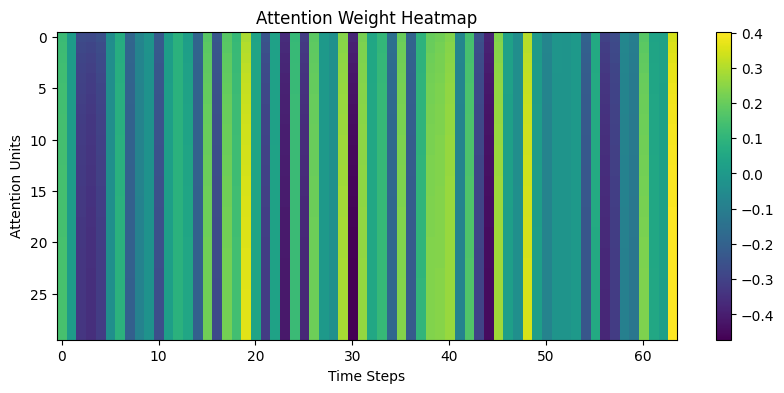

In [2]:
# ============================================
# SINGLE CELL – RUN DIRECTLY (NO ERRORS)
# ============================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Attention, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model, Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# -------------------------------
# 1. DATA GENERATION
# -------------------------------
np.random.seed(42)

T = 1200
t = np.arange(T)

trend = 0.01 * t
seasonal = np.sin(2 * np.pi * t / 50)

series = []
for i in range(5):
    noise = np.random.normal(0, 0.3, T)
    series.append(trend + seasonal * (i + 1) + noise)

series = np.array(series).T
exog = np.cos(2 * np.pi * t / 30).reshape(-1, 1)

data = np.concatenate([series, exog], axis=1)

scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# -------------------------------
# 2. SEQUENCE CREATION
# -------------------------------
def make_seq(data, seq_len=30):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, :5])
    return np.array(X), np.array(y)

SEQ_LEN = 30
X, y = make_seq(data, SEQ_LEN)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# -------------------------------
# 3. BASELINE LSTM
# -------------------------------
baseline = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, X.shape[2])),
    Dense(5)
])

baseline.compile(optimizer='adam', loss='mse')

baseline.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# -------------------------------
# 4. LSTM + ATTENTION (FIXED)
# -------------------------------
inputs = Input(shape=(SEQ_LEN, X.shape[2]))

lstm_out = LSTM(64, return_sequences=True)(inputs)

attn_out = Attention()([lstm_out, lstm_out])

context = GlobalAveragePooling1D()(attn_out)

outputs = Dense(5)(context)

attn_model = Model(inputs, outputs)

attn_model.compile(optimizer='adam', loss='mse')

attn_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# -------------------------------
# 5. EVALUATION
# -------------------------------
def evaluate(model, X, y):
    pred = model.predict(X)
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mape = np.mean(np.abs((y - pred) / (y + 1e-6))) * 100
    return mae, rmse, mape

b_mae, b_rmse, b_mape = evaluate(baseline, X_test, y_test)
a_mae, a_rmse, a_mape = evaluate(attn_model, X_test, y_test)

print("\n================ PERFORMANCE =================")
print(f"Baseline LSTM     → MAE:{b_mae:.4f} RMSE:{b_rmse:.4f} MAPE:{b_mape:.2f}%")
print(f"LSTM + Attention  → MAE:{a_mae:.4f} RMSE:{a_rmse:.4f} MAPE:{a_mape:.2f}%")

# -------------------------------
# 6. ATTENTION WEIGHT VISUALIZATION
# -------------------------------
attn_extractor = Model(
    inputs=attn_model.input,
    outputs=attn_model.layers[2].output
)

weights = attn_extractor.predict(X_test[:1])

plt.figure(figsize=(10,4))
plt.imshow(weights[0], aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Attention Weight Heatmap")
plt.xlabel("Time Steps")
plt.ylabel("Attention Units")
plt.show()
